In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

## Importing Data set

In [2]:
data = pd.read_csv("Z:\\Sasindu\\Data set\\electricity.csv", index_col=0, parse_dates=[0])

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head()

,Holiday,HolidayFlag,DayOfWeek,WeekOfYear,Day,Month,Year,PeriodOfDay,ForecastWindProduction,SystemLoadEA,SMPEA,ORKTemperature,ORKWindspeed,CO2Intensity,ActualWindProduction,SystemLoadEP2,SMPEP2
DateTime,,,,,,,,,,,,,,,,,
2011-01-11 00:00:00,None,0,1,44,1,11,2011,0,315.31,3388.77,49.26,6.00,9.30,600.71,356.00,3159.60,54.32
2011-01-11 00:30:00,None,0,1,44,1,11,2011,1,321.80,3196.66,49.26,6.00,11.10,605.42,317.00,2973.01,54.23
2011-01-11 01:00:00,None,0,1,44,1,11,2011,2,328.57,3060.71,49.10,5.00,11.10,589.97,311.00,2834.00,54.23
2011-01-11 01:30:00,None,0,1,44,1,11,2011,3,335.60,2945.56,48.04,6.00,9.30,585.94,313.00,2725.99,53.47
2011-01-11 02:00:00,None,0,1,44,1,11,2011,4,342.90,2849.34,33.75,6.00,11.10,571.52,346.00,2655.64,39.87


In [5]:
df.shape

(38014, 17)

## Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38014 entries, 2011-01-11 00:00:00 to 2013-12-31 23:30:00
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Holiday                 38014 non-null  object
 1   HolidayFlag             38014 non-null  int64 
 2   DayOfWeek               38014 non-null  int64 
 3   WeekOfYear              38014 non-null  int64 
 4   Day                     38014 non-null  int64 
 5   Month                   38014 non-null  int64 
 6   Year                    38014 non-null  int64 
 7   PeriodOfDay             38014 non-null  int64 
 8   ForecastWindProduction  38014 non-null  object
 9   SystemLoadEA            38014 non-null  object
 10  SMPEA                   38014 non-null  object
 11  ORKTemperature          38014 non-null  object
 12  ORKWindspeed            38014 non-null  object
 13  CO2Intensity            38014 non-null  object
 14  ActualWindProductio

##### Here, ForecastWindProduction, SystemLoadEA, SMPEA, ORKTemperature, ORKWindspeed, CO2Intensity, ActualWindProduction, SystemLoadEP2, SMPEP2 should be numeric values. Hance, Converting them into numeric type is needed.

In [7]:
cols_to_numeric = ['ForecastWindProduction', 'SystemLoadEA', 'SMPEA', 'ORKTemperature', 'ORKWindspeed', 'CO2Intensity', 'ActualWindProduction', 'SystemLoadEP2', 'SMPEP2']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38014 entries, 2011-01-11 00:00:00 to 2013-12-31 23:30:00
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Holiday                 38014 non-null  object 
 1   HolidayFlag             38014 non-null  int64  
 2   DayOfWeek               38014 non-null  int64  
 3   WeekOfYear              38014 non-null  int64  
 4   Day                     38014 non-null  int64  
 5   Month                   38014 non-null  int64  
 6   Year                    38014 non-null  int64  
 7   PeriodOfDay             38014 non-null  int64  
 8   ForecastWindProduction  38009 non-null  float64
 9   SystemLoadEA            38012 non-null  float64
 10  SMPEA                   38012 non-null  float64
 11  ORKTemperature          37719 non-null  float64
 12  ORKWindspeed            37715 non-null  float64
 13  CO2Intensity            38007 non-null  float64
 14  Act

In [8]:
missing_values =df.isnull().sum()
print(missing_values)

Holiday                     0
HolidayFlag                 0
DayOfWeek                   0
WeekOfYear                  0
Day                         0
Month                       0
Year                        0
PeriodOfDay                 0
ForecastWindProduction      5
SystemLoadEA                2
SMPEA                       2
ORKTemperature            295
ORKWindspeed              299
CO2Intensity                7
ActualWindProduction        5
SystemLoadEP2               2
SMPEP2                      2
dtype: int64


##### Before fill missing values, Exploratory data Analysis is essential.

## Exploratory data Analysis

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

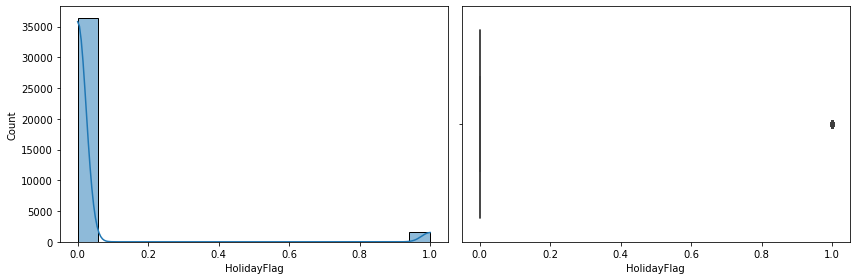

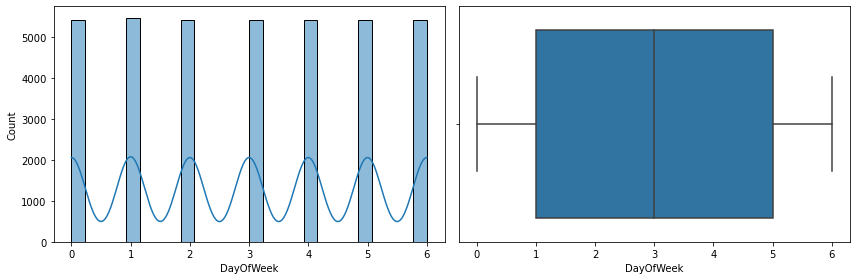

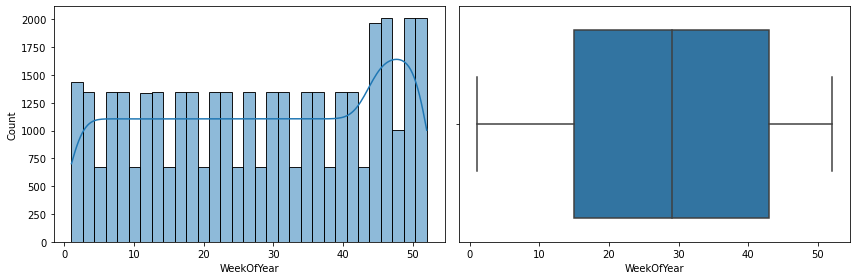

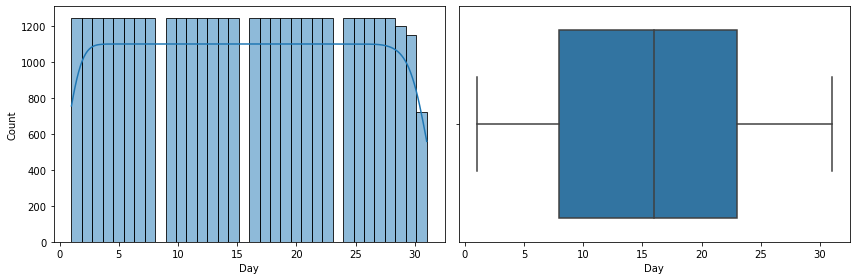

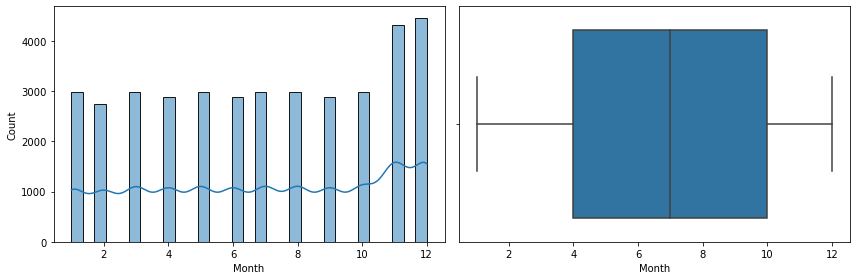

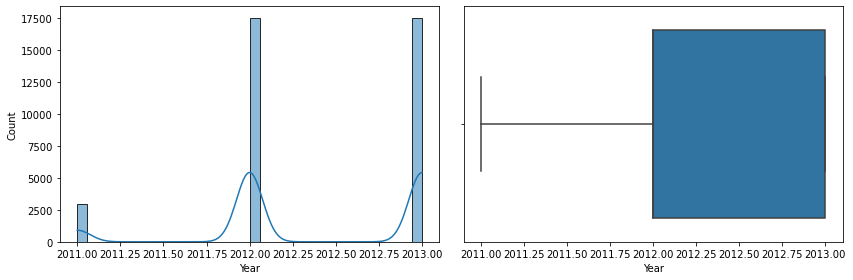

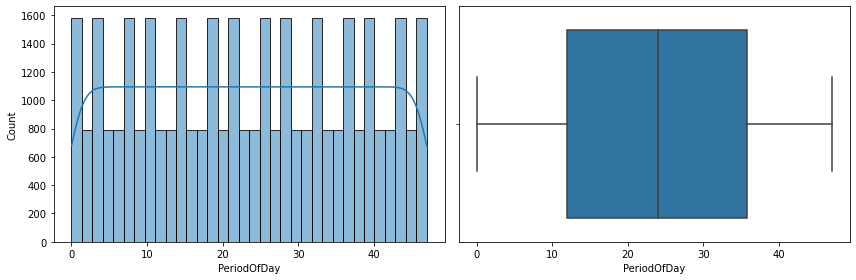

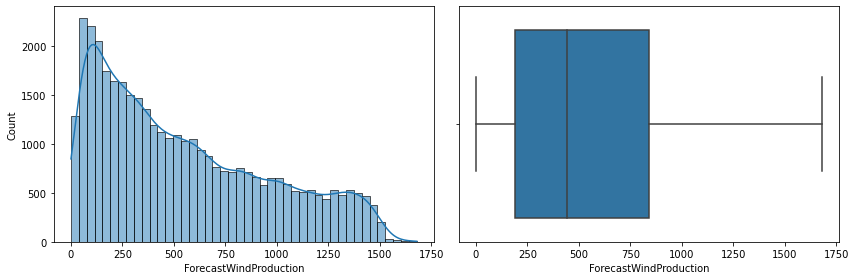

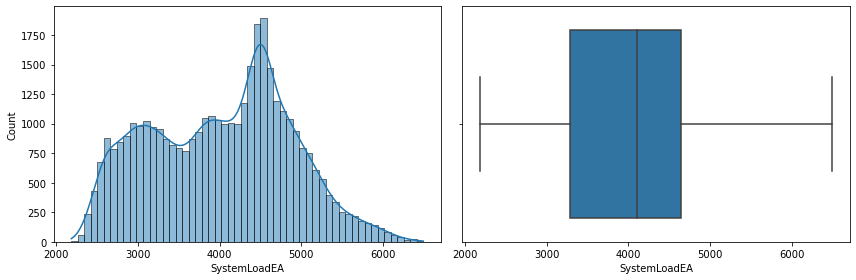

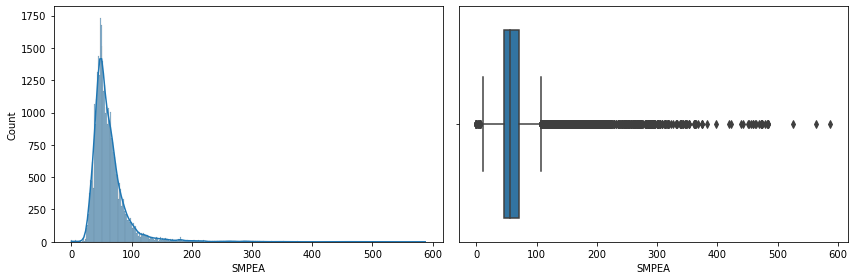

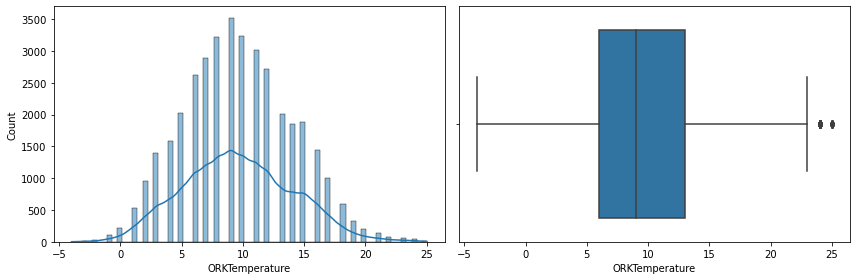

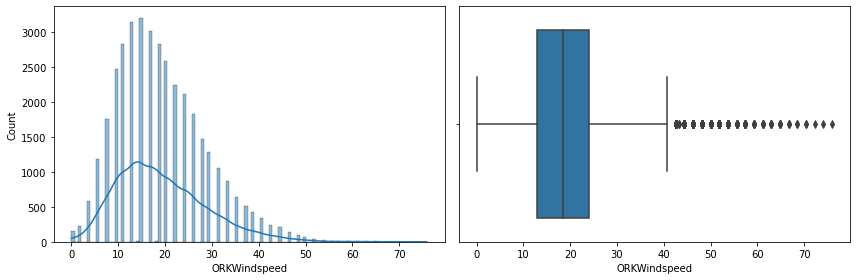

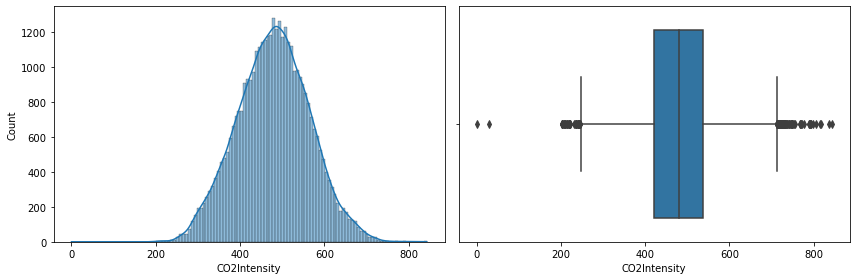

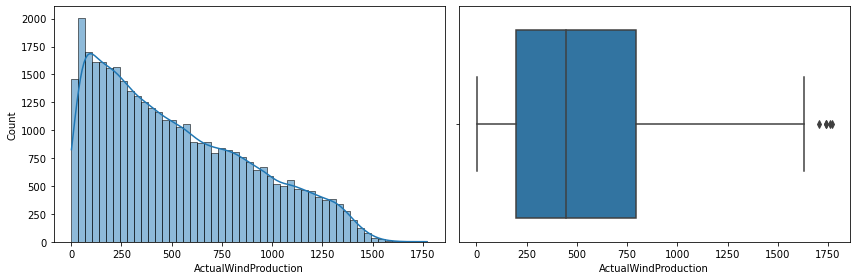

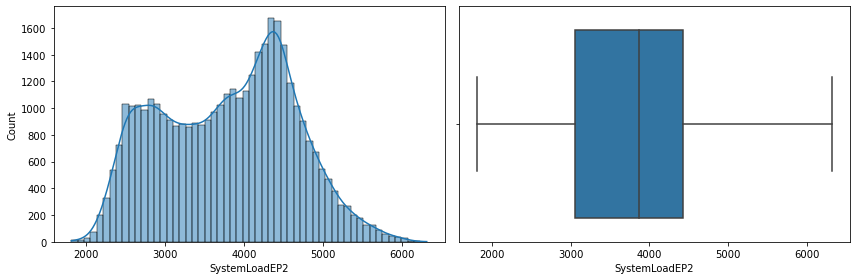

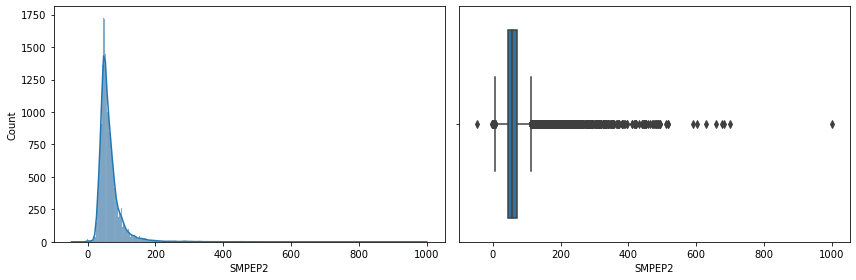

In [10]:
numeric_vals = ['HolidayFlag', 'DayOfWeek', 'WeekOfYear', 'Day', 'Month', 'Year', 'PeriodOfDay',
               'ForecastWindProduction', 'SystemLoadEA', 'SMPEA', 'ORKTemperature', 'ORKWindspeed',
                'CO2Intensity', 'ActualWindProduction', 'SystemLoadEP2', 'SMPEP2']
for col in numeric_vals:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.tight_layout()
    plt.show()

In [11]:
df.describe()

,HolidayFlag,DayOfWeek,WeekOfYear,Day,Month,Year,PeriodOfDay,ForecastWindProduction,SystemLoadEA,SMPEA,ORKTemperature,ORKWindspeed,CO2Intensity,ActualWindProduction,SystemLoadEP2,SMPEP2
count,38014.000000,38014.000000,38014.000000,38014.000000,38014.000000,38014.000000,38014.000000,38009.000000,38012.000000,38012.000000,37719.000000,37715.000000,38007.000000,38009.000000,38012.000000,38012.000000
mean,0.040406,2.997317,28.124586,15.739412,6.904246,2012.383859,23.501105,544.261451,4020.085019,62.720388,9.626369,19.211770,479.373040,520.762819,3785.973841,64.136823
std,0.196912,1.999959,15.587575,8.804247,3.573696,0.624956,13.853108,414.364629,860.476866,32.252334,4.439934,9.571311,85.354706,378.282975,843.269455,35.415036
min,0.000000,0.000000,1.000000,1.000000,1.000000,2011.000000,0.000000,0.680000,2183.940000,0.000000,-4.000000,0.000000,0.000000,1.000000,1809.960000,-47.740000
25%,0.000000,1.000000,15.000000,8.000000,4.000000,2012.000000,12.000000,189.670000,3281.207500,45.530000,6.000000,13.000000,421.105000,199.000000,3058.277500,45.780000
50%,0.000000,3.000000,29.000000,16.000000,7.000000,2012.000000,24.000000,441.980000,4103.600000,55.230000,9.000000,18.500000,480.310000,445.000000,3865.745000,55.545000
75%,0.000000,5.000000,43.000000,23.000000,10.000000,2013.000000,35.750000,839.460000,4638.532500,70.320000,13.000000,24.100000,537.520000,793.000000,4427.590000,72.110000
max,1.000000,6.000000,52.000000,31.000000,12.000000,2013.000000,47.000000,1680.000000,6492.910000,587.580000,25.000000,75.900000,842.880000,1769.000000,6309.750000,1000.000000


### Handling missing values

In [12]:
df.replace(['', 'NA', 'N/A', None], np.nan, inplace=True)

In [13]:
df_cleaned = df.dropna(subset=['ORKTemperature','ORKWindspeed'])

In [14]:
df_cleaned.shape

(37689, 17)

##### Because of having more missing values in ORKTemperature, ORKWindspeed columns, If they filled with mean or median, it can be error for model. So Null values were removed.

### Removing Outliers

In [15]:
SMPEP2_out = (df_cleaned['SMPEP2'] > 0) | (df_cleaned['SMPEP2'] <= 550)

In [16]:
df_cleaned = df_cleaned[SMPEP2_out]

In [17]:
df_cleaned.shape

(37689, 17)

In [18]:
fill_with_median = ['ForecastWindProduction','SystemLoadEA','SMPEA','ActualWindProduction', 'SystemLoadEP2', 'SMPEP2']
for col in fill_with_median:
    median_col = df_cleaned[col].median()
    df_cleaned[col].fillna(median_col,inplace=True)

##### Because of having skewed distribution on 'ForecastWindProduction','SystemLoadEA','SMPEA','ActualWindProduction', 'SystemLoadEP2', 'SMPEP2' columns. Missing values were filled with median.

In [19]:
mean_CO2Intensity = df_cleaned['CO2Intensity'].mean()
df_cleaned['CO2Intensity'].fillna(mean_CO2Intensity,inplace=True)

##### CO2Intensity has normal dustribution. So null values were filled with mean value of the CO2Intensity.

In [20]:
missing_values =df_cleaned.isna().sum()
print(missing_values)

Holiday                   0
HolidayFlag               0
DayOfWeek                 0
WeekOfYear                0
Day                       0
Month                     0
Year                      0
PeriodOfDay               0
ForecastWindProduction    0
SystemLoadEA              0
SMPEA                     0
ORKTemperature            0
ORKWindspeed              0
CO2Intensity              0
ActualWindProduction      0
SystemLoadEP2             0
SMPEP2                    0
dtype: int64


In [21]:
df_cleaned.head()

,Holiday,HolidayFlag,DayOfWeek,WeekOfYear,Day,Month,Year,PeriodOfDay,ForecastWindProduction,SystemLoadEA,SMPEA,ORKTemperature,ORKWindspeed,CO2Intensity,ActualWindProduction,SystemLoadEP2,SMPEP2
DateTime,,,,,,,,,,,,,,,,,
2011-01-11 00:00:00,None,0,1,44,1,11,2011,0,315.31,3388.77,49.26,6.0,9.3,600.71,356.0,3159.60,54.32
2011-01-11 00:30:00,None,0,1,44,1,11,2011,1,321.80,3196.66,49.26,6.0,11.1,605.42,317.0,2973.01,54.23
2011-01-11 01:00:00,None,0,1,44,1,11,2011,2,328.57,3060.71,49.10,5.0,11.1,589.97,311.0,2834.00,54.23
2011-01-11 01:30:00,None,0,1,44,1,11,2011,3,335.60,2945.56,48.04,6.0,9.3,585.94,313.0,2725.99,53.47
2011-01-11 02:00:00,None,0,1,44,1,11,2011,4,342.90,2849.34,33.75,6.0,11.1,571.52,346.0,2655.64,39.87


### EDA (Correlation Analysis)

<Figure size 1440x1440 with 0 Axes>

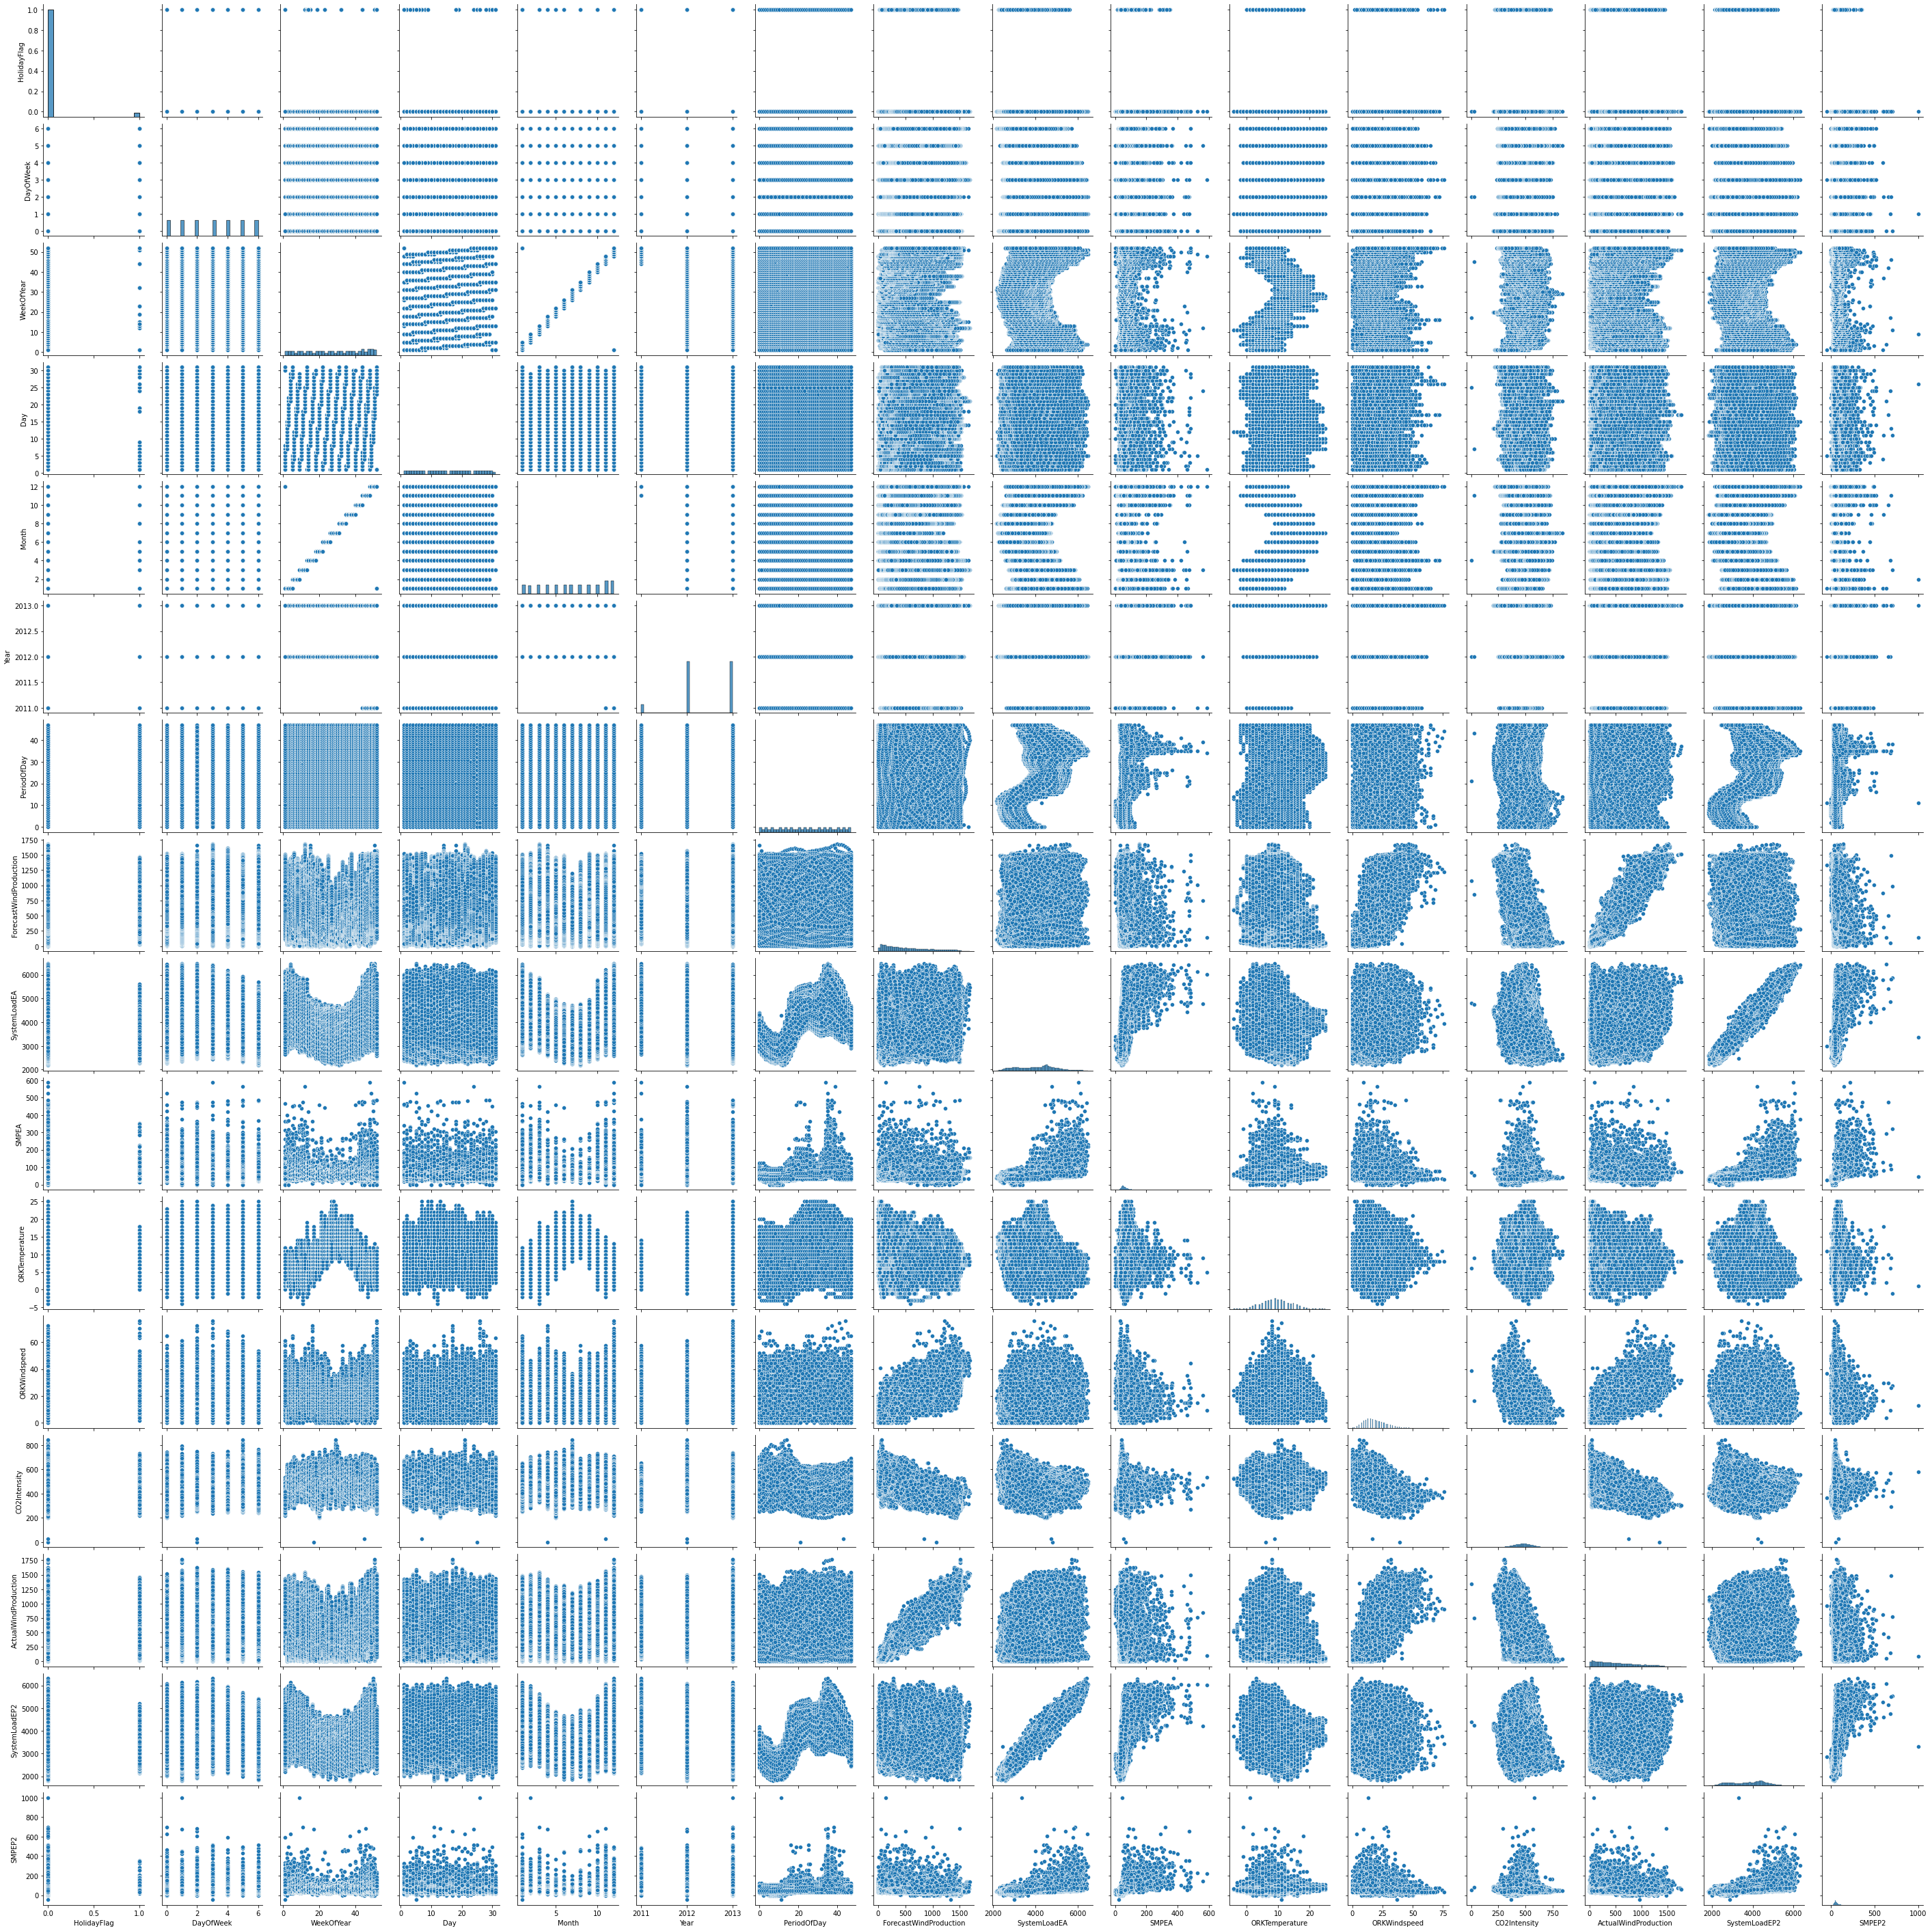

In [22]:
plt.figure(figsize=(20, 20))
sns.pairplot(df_cleaned,palette='set1')
plt.show()

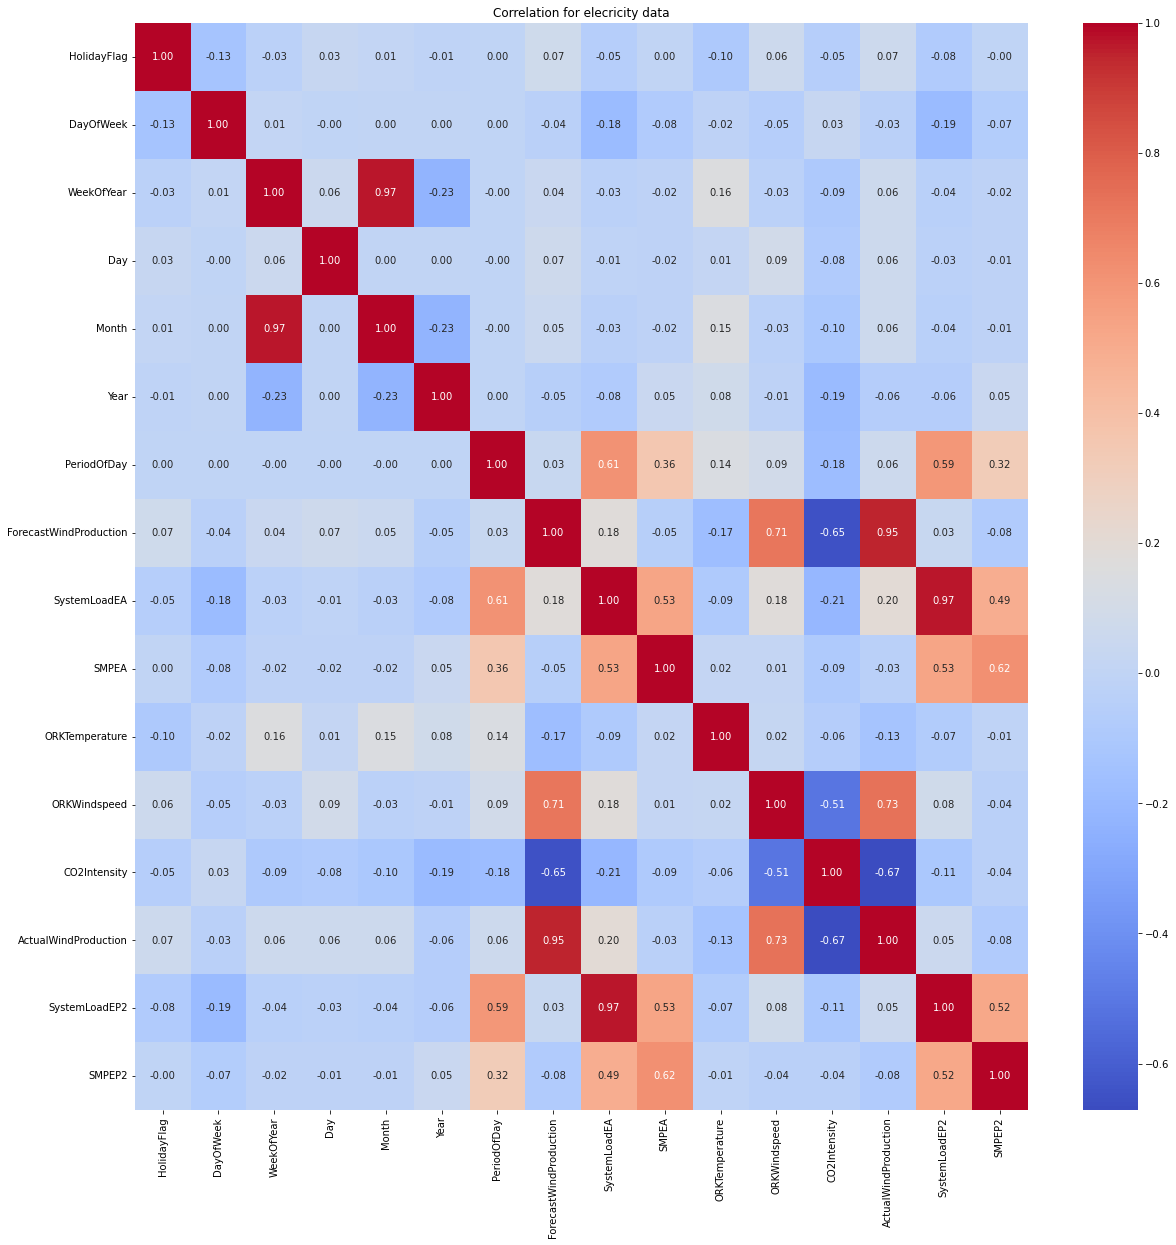

In [23]:
numeric_df = df_cleaned.select_dtypes(include = ['number'])
corr_matrix =numeric_df.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm',fmt=".2f")
plt.title('Correlation for elecricity data')
plt.show()

#### By studing Heatmap, Following observations can be gathered.
###### Highly positive correlation between month and weekofyear
###### Highly positive correlation between ForecastWindProduction and ActualWindProduction
###### Highly positive correlation between SystemLoadEA and SystemLoadEA2
###### Highly positive correlation between ORKWindspeed and ForecastWindProduction
###### Highly positive correlation between ORKWindspeed and ActualWindProduction

####  If some features in dataset have high correlation, it is often a good idea to consider ignoring or removing one of the highly correlated features.
#### It can be cause to multicolinearity, increase model complexity, reduse model performence. Hance, one feature can be ignored.
###### ** Month might be more straightforward and useful in many contexts compared to WeekOfYear. So ,WeekOfYear was removed.
###### ** To get more accurate model, I think removing ForecastWindProduction column is suitable.
###### ** SystemLoadEA is forecasted national load and SystemLoadEA2 is actual national system load. hance, Removing SystemLoadEA is more accurate.
###### ** Because of model requament, ORKWindspeed or ActualWindProduction weren't removed. ForecastWindProduction has already removed.
###### ** Holiday column is also populated. Hence, Holiday column can be removed.

In [24]:
df_new = df_cleaned.drop(columns=['Holiday','WeekOfYear','ForecastWindProduction','SystemLoadEA'])

In [25]:
df_new.head()

,HolidayFlag,DayOfWeek,Day,Month,Year,PeriodOfDay,SMPEA,ORKTemperature,ORKWindspeed,CO2Intensity,ActualWindProduction,SystemLoadEP2,SMPEP2
DateTime,,,,,,,,,,,,,
2011-01-11 00:00:00,0,1,1,11,2011,0,49.26,6.0,9.3,600.71,356.0,3159.60,54.32
2011-01-11 00:30:00,0,1,1,11,2011,1,49.26,6.0,11.1,605.42,317.0,2973.01,54.23
2011-01-11 01:00:00,0,1,1,11,2011,2,49.10,5.0,11.1,589.97,311.0,2834.00,54.23
2011-01-11 01:30:00,0,1,1,11,2011,3,48.04,6.0,9.3,585.94,313.0,2725.99,53.47
2011-01-11 02:00:00,0,1,1,11,2011,4,33.75,6.0,11.1,571.52,346.0,2655.64,39.87


In [26]:
df_new.shape

(37689, 13)

#### Split Date and timestamp from index

In [27]:
df_scaled = df_new.reset_index()

In [28]:
df_scaled.columns

Index(['DateTime', 'HolidayFlag', 'DayOfWeek', 'Day', 'Month', 'Year',
       'PeriodOfDay', 'SMPEA', 'ORKTemperature', 'ORKWindspeed',
       'CO2Intensity', 'ActualWindProduction', 'SystemLoadEP2', 'SMPEP2'],
      dtype='object')

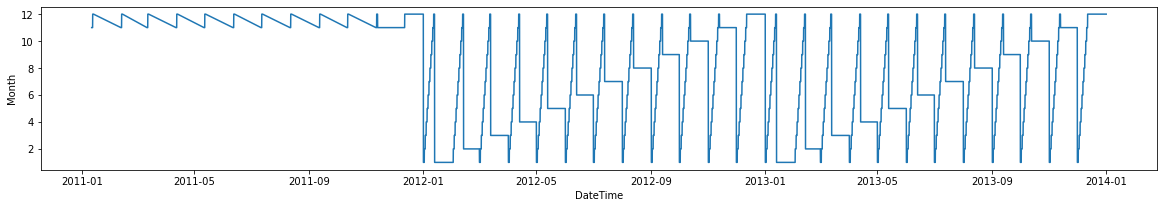

In [29]:
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,3))
sns.lineplot(x=df_scaled.DateTime, y = df_scaled.Month)
plt.show()

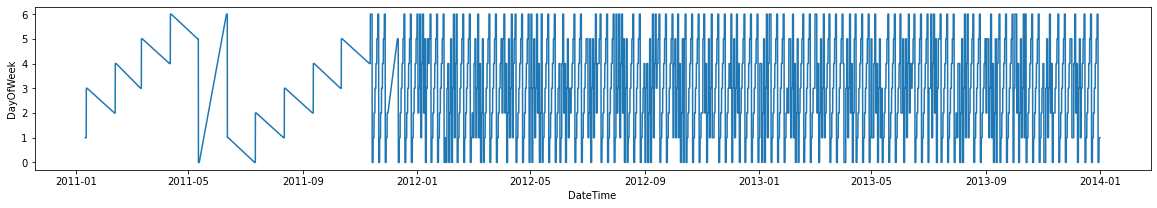

In [30]:
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,3))
sns.lineplot(x=df_scaled.DateTime, y = df_scaled.DayOfWeek)
plt.show()

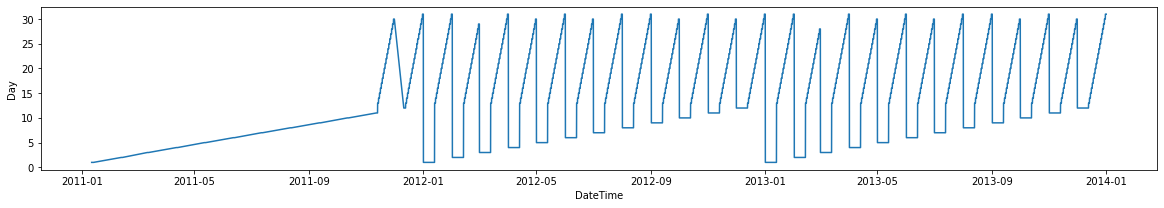

In [31]:
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,3))
sns.lineplot(x=df_scaled.DateTime, y = df_scaled.Day)
plt.show()

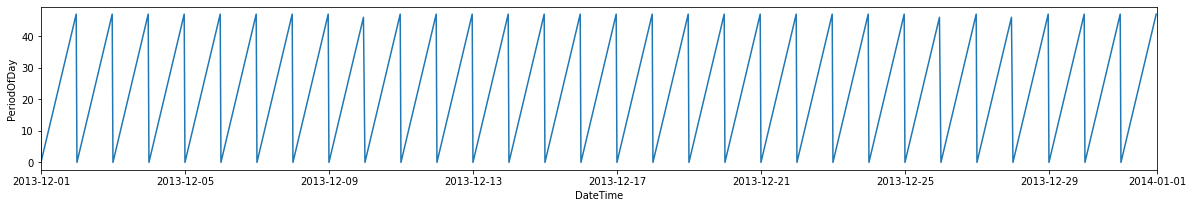

In [32]:
from datetime import date

f, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,3))
sns.lineplot(x=df_scaled.DateTime, y = df_scaled.PeriodOfDay)
ax.set_xlim([date(2013,12,1),date(2014,1,1)])
plt.show()

##### By looking above graphs, We can see cyclic nature.Convert cyclic features into two continuous features using sine and cosine transformations to preserve the cyclic nature.Sine and Cosine functions help in representing the cyclic nature by mapping the feature to a circle. 

## Feature Engineering

In [33]:
def periodic_transform(df, variable, period, offset=0):
    angle = (df[variable] - offset) / period * 2 * np.pi
    df[f"{variable}_SIN"] = np.sin(angle)
    df[f"{variable}_COS"] = np.cos(angle)
    return df

In [34]:
df_scaled = periodic_transform(df_scaled, 'DayOfWeek')
df_scaled = periodic_transform(df_scaled, 'Day')
df_scaled = periodic_transform(df_scaled, 'Month')
df_scaled = periodic_transform(df_scaled, 'PeriodOfDay')
df_scaled.head()

,DateTime,HolidayFlag,DayOfWeek,Day,Month,Year,PeriodOfDay,SMPEA,ORKTemperature,ORKWindspeed,...,SystemLoadEP2,SMPEP2,DayOfWeek_SIN,DayOfWeek_COS,Day_SIN,Day_COS,Month_SIN,Month_COS,PeriodOfDay_SIN,PeriodOfDay_COS
0,2011-01-11 00:00:00,0,1,1,11,2011,0,49.26,6.0,9.3,...,3159.60,54.32,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.000000,1.000000
1,2011-01-11 00:30:00,0,1,1,11,2011,1,49.26,6.0,11.1,...,2973.01,54.23,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.133287,0.991077
2,2011-01-11 01:00:00,0,1,1,11,2011,2,49.10,5.0,11.1,...,2834.00,54.23,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.264195,0.964469
3,2011-01-11 01:30:00,0,1,1,11,2011,3,48.04,6.0,9.3,...,2725.99,53.47,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.390389,0.920650
4,2011-01-11 02:00:00,0,1,1,11,2011,4,33.75,6.0,11.1,...,2655.64,39.87,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.509617,0.860402


##### Hence, DayOfWeek, Day, Month, and PeriodOfDay  columns can be removed.

In [35]:
df_scaled = df_scaled.drop(columns=['DateTime','DayOfWeek','Day','Month','PeriodOfDay'])

In [36]:
df_scaled.columns

Index(['HolidayFlag', 'Year', 'SMPEA', 'ORKTemperature', 'ORKWindspeed',
       'CO2Intensity', 'ActualWindProduction', 'SystemLoadEP2', 'SMPEP2',
       'DayOfWeek_SIN', 'DayOfWeek_COS', 'Day_SIN', 'Day_COS', 'Month_SIN',
       'Month_COS', 'PeriodOfDay_SIN', 'PeriodOfDay_COS'],
      dtype='object')

In [37]:
df_scaled.head()

,HolidayFlag,Year,SMPEA,ORKTemperature,ORKWindspeed,CO2Intensity,ActualWindProduction,SystemLoadEP2,SMPEP2,DayOfWeek_SIN,DayOfWeek_COS,Day_SIN,Day_COS,Month_SIN,Month_COS,PeriodOfDay_SIN,PeriodOfDay_COS
0,0,2011,49.26,6.0,9.3,600.71,356.0,3159.60,54.32,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.000000,1.000000
1,0,2011,49.26,6.0,11.1,605.42,317.0,2973.01,54.23,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.133287,0.991077
2,0,2011,49.10,5.0,11.1,589.97,311.0,2834.00,54.23,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.264195,0.964469
3,0,2011,48.04,6.0,9.3,585.94,313.0,2725.99,53.47,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.390389,0.920650
4,0,2011,33.75,6.0,11.1,571.52,346.0,2655.64,39.87,0.866025,0.5,0.201299,0.97953,-0.5,0.866025,0.509617,0.860402


### Splitting Data

In [38]:
x = df_scaled.drop(columns = 'SMPEP2', axis = 1)
y = df_scaled['SMPEP2']

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

### Scaling data

#### HolidayFlag column 0 and 1 values. Hence, no need to encord this column.
#### As most of columns having skewed distribution, minmaxscaler canbe applied for those columns such as Year,SMPEA,ORKTemperature,ORKWindspeed,ActualWindProduction,CO2Intensity,SystemLoadEP2,and SMPEP2


In [41]:
from sklearn.preprocessing import MinMaxScaler

In [42]:
mm = MinMaxScaler()
x_train_scaled = mm.fit_transform(x_train)
x_test_scaled = mm.transform(x_test)

### Define Model

#### Defining modes for scaled Data

In [43]:
def model_acc(model):
    model.fit(x_train_scaled,y_train)
    acc = model.score(x_test_scaled,y_test)
    print(str(model)+'-->'+str(acc))

In [44]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model_acc(lr)

from sklearn.linear_model import Lasso
lasso = Lasso()
model_acc(lasso)

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
model_acc(dt)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
model_acc(rf)

from sklearn.svm import SVR
svm = SVR()
model_acc(svm)

LinearRegression()-->0.48905676867606707
Lasso()-->0.2772854301397977
DecisionTreeRegressor()-->0.2697524173454505
RandomForestRegressor()-->0.6502949319671649
SVR()-->0.37460328300674395


In [45]:
best_model = rf

In [46]:
y_test_pred = best_model.predict(x_test_scaled)

### Evaluation for Scaled Data for Best Model

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_pacf

In [48]:
y_test_pred = y_test_pred.flatten()

In [49]:
final_df = pd.DataFrame(np.hstack((y_test_pred[:, np.newaxis], y_test[:, np.newaxis])), columns=['Prediction', 'Real'])

In [50]:
print(f'MAE: {mean_absolute_error(final_df["Prediction"],final_df["Real"])}')
print(f'MSE: {mean_squared_error(final_df["Prediction"],final_df["Real"])}')

MAE: 8.561185646059963
MSE: 407.19281815597776


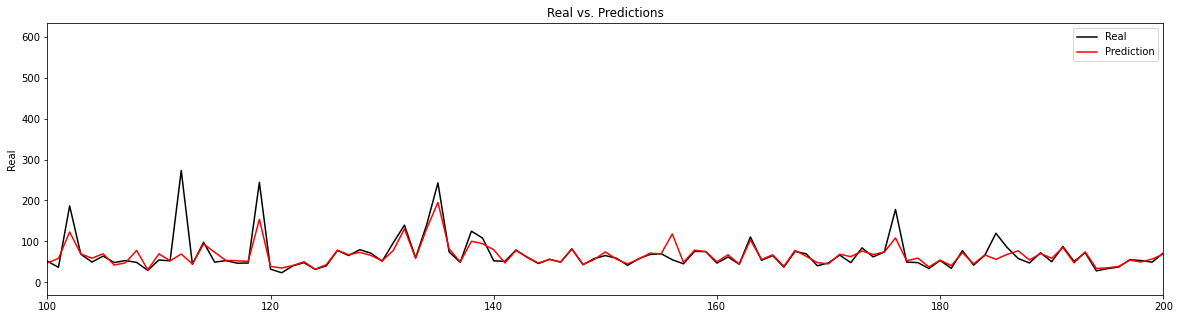

In [51]:
fig, ax = plt.subplots(figsize=(20, 5))
sns.lineplot(x=range(len(final_df['Real'])) ,y=final_df['Real'],color='black',label='Real')
sns.lineplot(x=range(len(final_df['Prediction'])),y=final_df['Prediction'],color='red',label='Prediction')
ax.set_xlim([100,200])
plt.title('Real vs. Predictions')
plt.show()

### PCA

In [52]:
from sklearn.decomposition import PCA

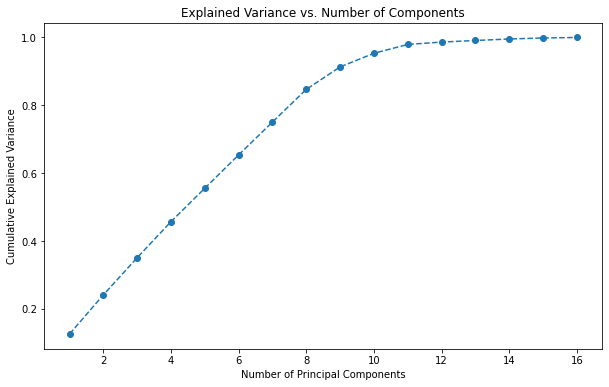

In [53]:
pca = PCA()
pca.fit(x_train_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()

In [54]:
pca = PCA(n_components= 11)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [55]:
def model_acc_pca(model):
    model.fit(x_train_pca,y_train)
    acc = model.score(x_test_pca,y_test)
    print(str(model)+'-->'+str(acc))

In [56]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model_acc_pca(lr)

from sklearn.linear_model import Lasso
lasso = Lasso()
model_acc_pca(lasso)

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
model_acc_pca(dt)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
model_acc_pca(rf)

from sklearn.svm import SVR
svm = SVR()
model_acc_pca(svm)

LinearRegression()-->0.27757764666830176
Lasso()-->0.2188336116695484
DecisionTreeRegressor()-->0.10041291628926752
RandomForestRegressor()-->0.5839351607802757
SVR()-->0.28157307632318906


##### Here, The best model can be defined as Random Forest Regressor. But here, model score is lower than modelling without PCA transformed Data. Hence, Previous senario can be applied.

### Defining modes for Data Without scaling and PCA

In [57]:
df_new.head()

,HolidayFlag,DayOfWeek,Day,Month,Year,PeriodOfDay,SMPEA,ORKTemperature,ORKWindspeed,CO2Intensity,ActualWindProduction,SystemLoadEP2,SMPEP2
DateTime,,,,,,,,,,,,,
2011-01-11 00:00:00,0,1,1,11,2011,0,49.26,6.0,9.3,600.71,356.0,3159.60,54.32
2011-01-11 00:30:00,0,1,1,11,2011,1,49.26,6.0,11.1,605.42,317.0,2973.01,54.23
2011-01-11 01:00:00,0,1,1,11,2011,2,49.10,5.0,11.1,589.97,311.0,2834.00,54.23
2011-01-11 01:30:00,0,1,1,11,2011,3,48.04,6.0,9.3,585.94,313.0,2725.99,53.47
2011-01-11 02:00:00,0,1,1,11,2011,4,33.75,6.0,11.1,571.52,346.0,2655.64,39.87


In [58]:
df_new = df_new.reset_index()

In [59]:
df_new.head()

,DateTime,HolidayFlag,DayOfWeek,Day,Month,Year,PeriodOfDay,SMPEA,ORKTemperature,ORKWindspeed,CO2Intensity,ActualWindProduction,SystemLoadEP2,SMPEP2
0,2011-01-11 00:00:00,0,1,1,11,2011,0,49.26,6.0,9.3,600.71,356.0,3159.60,54.32
1,2011-01-11 00:30:00,0,1,1,11,2011,1,49.26,6.0,11.1,605.42,317.0,2973.01,54.23
2,2011-01-11 01:00:00,0,1,1,11,2011,2,49.10,5.0,11.1,589.97,311.0,2834.00,54.23
3,2011-01-11 01:30:00,0,1,1,11,2011,3,48.04,6.0,9.3,585.94,313.0,2725.99,53.47
4,2011-01-11 02:00:00,0,1,1,11,2011,4,33.75,6.0,11.1,571.52,346.0,2655.64,39.87


In [60]:
X = df_new.drop(columns = ['DateTime','SMPEP2'],axis=1)

In [61]:
Y = df_new['SMPEP2']

In [62]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [63]:
def model_acc_no_scale(model):
    model.fit(X_train,Y_train)
    acc = model.score(X_test,Y_test)
    print(str(model)+'-->'+str(acc))

In [64]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model_acc_no_scale(lr)

from sklearn.linear_model import Lasso
lasso = Lasso()
model_acc_no_scale(lasso)

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
model_acc_no_scale(dt)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
model_acc_no_scale(rf)

from sklearn.svm import SVR
svm = SVR()
model_acc_no_scale(svm)

LinearRegression()-->0.48224984365904056
Lasso()-->0.48025129059454563
DecisionTreeRegressor()-->0.20583880963883538
RandomForestRegressor()-->0.6393079837864907
SVR()-->0.27434962878349034


#### Here also, the best model is Random Forest Regressor and it's score is lower than modelling with the scaled data.

## Conclution

###### According To previous results, In this senario, Data can be used with out PCA transformiong. 
###### The most suitable model is Random Forest Regressor and it's model score (R^2) is 0.6502.
###### Here, the mean absolute error is 8.5611 and the mean squared error is 407.1928. those parameters are less values.
###### By studing the graph of "Real vs. Predictions", Similer patterns can be seen.
###### Hence, Random Forest Regressor can be defined as the most suitable model for the electricity data among "LinearRegression","Lasso","DecisionTreeRegressor","RandomForestRegressor", and "SVR".